In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import unicodedata

from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [39]:
df = pd.read_csv('database/test.csv')
#df = pd.read_csv('database/train_mod.csv')
df.head()

,ID,Débitos,Fabricante,Modelo,Ano,Categoria,Couro,Combustivel,Volume_motor,Km,...,Airbags,Preco,Numero_proprietarios,Data_ultima_lavagem,Adesivos_personalizados,Radio_AM_FM,Historico_troca_oleo,Codigo_concessionaria,Classificacao_Veiculo,Faixa_Preco
0,45804429,1017,HYUNDAI,Tucson,2017,SUV,Sim,Dies.,2,48089 km,...,4,40556.0,5,2022-11-19,Não,FM,8,4776,Usado,Médio
1,45768909,-,MERCEDES-BENZ,C 180,1995,Sedan,Nao,gasolina,1.8 Turbo,NaN,...,2,5331.0,2,2021-09-30,Sim,FM,1,7983,Usado,Econômico
2,45788796,836,BMW,118,2010,Sedan,Sim,Diesel,2,197000 km,...,0,18817.0,5,2021-05-08,Sim,AM,6,2664,Usado,Econômico
3,42974578,891,KIA,Sportage SX,2016,SUV,Sim,Gasolina,2.0 Turbo,55447 km,...,10,22894.0,5,2021-06-11,Não,FM,5,8234,Usado,Médio
4,45801622,583,HYUNDAI,Elantra,2011,Sedan,Sim,Gasolina,1.6,106616 km,...,4,20005.0,1,2021-12-05,Sim,AM,1,5769,Usado,Médio


In [40]:
df.shape

(17370, 26)

In [41]:
df["Fabricante"].value_counts()

Fabricante
TOYOTA           3295
HYUNDAI          2954
MERCEDES-BENZ    1967
FORD             1044
CHEVROLET         969
                 ... 
TATA                1
TESLA               1
FOTON               1
MG                  1
BENTLEY             1
Name: count, Length: 65, dtype: int64

In [42]:
df["Ano"].value_counts()

Ano
2012    2022
2014    1857
2013    1845
2011    1536
2010    1351
2015    1301
2016    1208
2017     866
2008     715
2009     580
2018     432
2007     431
2005     368
2003     325
2004     304
2006     280
2019     277
2001     242
2000     240
2002     231
1999     203
1998     182
1997     140
1996     107
1995      80
2020      59
1994      44
1993      30
1992      26
1990      21
1988      10
1987       9
1991       9
1986       5
1989       4
1939       3
1985       3
1980       2
1968       2
1981       2
1953       2
1970       1
1966       1
1956       1
1943       1
1979       1
1961       1
1974       1
1965       1
1973       1
1977       1
1982       1
1957       1
1978       1
1947       1
1964       1
1984       1
Name: count, dtype: int64

In [43]:
df["Categoria"].value_counts()

Categoria
Sedan             7632
SUV               5130
Hatchback         2612
Minivan            588
Cupê               475
Universal          343
Microonibus        300
Vagao de carga     191
Picape              47
Conversivel         43
Limousine            9
Name: count, dtype: int64

In [44]:
df["Combustivel"].value_counts()

Combustivel
Gasolina       3701
Hibrido        3379
GASOLINA       2338
Gasol.         1923
gasolina       1628
Diesel         1557
DIESEL          942
Dies.           775
diesel          658
Gás Natural     469
Name: count, dtype: int64

In [45]:
df["Ano"].value_counts()

Ano
2012    2022
2014    1857
2013    1845
2011    1536
2010    1351
2015    1301
2016    1208
2017     866
2008     715
2009     580
2018     432
2007     431
2005     368
2003     325
2004     304
2006     280
2019     277
2001     242
2000     240
2002     231
1999     203
1998     182
1997     140
1996     107
1995      80
2020      59
1994      44
1993      30
1992      26
1990      21
1988      10
1987       9
1991       9
1986       5
1989       4
1939       3
1985       3
1980       2
1968       2
1981       2
1953       2
1970       1
1966       1
1956       1
1943       1
1979       1
1961       1
1974       1
1965       1
1973       1
1977       1
1982       1
1957       1
1978       1
1947       1
1964       1
1984       1
Name: count, dtype: int64

In [46]:
df["Débitos"] = pd.to_numeric(
    df["Débitos"].replace("-", np.nan),
    errors="coerce"
)

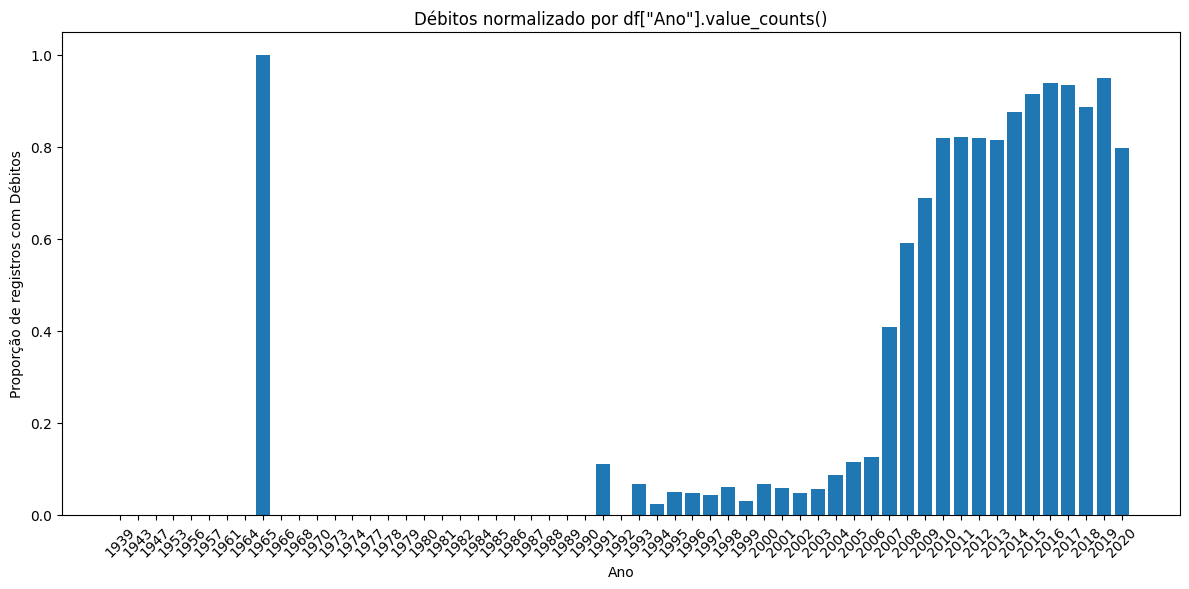

In [47]:
df["Ano"] = pd.to_numeric(df["Ano"], errors="coerce")

# Total de registros por ano
total_por_ano = df["Ano"].value_counts().sort_index()

# Quantidade de registros com Débitos válidos por ano
com_debito_por_ano = df.dropna(subset=["Ano", "Débitos"])["Ano"].value_counts().sort_index()

# Normalização pela contagem total de registros do ano
normalizado = (com_debito_por_ano / total_por_ano).fillna(0).sort_index()

graf = normalizado.reset_index()
graf.columns = ["Ano", "Proporcao_com_Debito"]

plt.figure(figsize=(12, 6))
plt.bar(graf["Ano"].astype(int).astype(str), graf["Proporcao_com_Debito"])
plt.xlabel("Ano")
plt.ylabel("Proporção de registros com Débitos")
plt.title('Débitos normalizado por df["Ano"].value_counts()')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [48]:
df = df[df["Preco"].notna()].copy()
df.head()

,ID,Débitos,Fabricante,Modelo,Ano,Categoria,Couro,Combustivel,Volume_motor,Km,...,Airbags,Preco,Numero_proprietarios,Data_ultima_lavagem,Adesivos_personalizados,Radio_AM_FM,Historico_troca_oleo,Codigo_concessionaria,Classificacao_Veiculo,Faixa_Preco
0,45804429,1017.0,HYUNDAI,Tucson,2017,SUV,Sim,Dies.,2,48089 km,...,4,40556.0,5,2022-11-19,Não,FM,8,4776,Usado,Médio
1,45768909,NaN,MERCEDES-BENZ,C 180,1995,Sedan,Nao,gasolina,1.8 Turbo,NaN,...,2,5331.0,2,2021-09-30,Sim,FM,1,7983,Usado,Econômico
2,45788796,836.0,BMW,118,2010,Sedan,Sim,Diesel,2,197000 km,...,0,18817.0,5,2021-05-08,Sim,AM,6,2664,Usado,Econômico
3,42974578,891.0,KIA,Sportage SX,2016,SUV,Sim,Gasolina,2.0 Turbo,55447 km,...,10,22894.0,5,2021-06-11,Não,FM,5,8234,Usado,Médio
4,45801622,583.0,HYUNDAI,Elantra,2011,Sedan,Sim,Gasolina,1.6,106616 km,...,4,20005.0,1,2021-12-05,Sim,AM,1,5769,Usado,Médio


In [49]:
df["Km"].value_counts()

Km
0 km         311
200000 km     86
150000 km     74
180000 km     53
100000 km     50
            ... 
116644 km      1
1792 km        1
170971 km      1
156887 km      1
186923 km      1
Name: count, Length: 3898, dtype: int64

In [50]:
df["Km"] = pd.to_numeric(
    df["Km"]
      .astype(str)
      .str.strip()
      .str.replace(" km", "", regex=False)
      .str.replace(".", "", regex=False)
      .str.replace(",", ".", regex=False),
    errors="coerce"
)

In [51]:
df["Km"].value_counts()

Km
0.0         311
200000.0     86
150000.0     74
180000.0     53
100000.0     50
           ... 
116644.0      1
1792.0        1
170971.0      1
156887.0      1
186923.0      1
Name: count, Length: 3898, dtype: int64

In [52]:
df["Volume_motor"].value_counts()

Volume_motor
2            1646
2.5          1100
1.8           846
1.6           703
1.5           661
             ... 
0.4 Turbo       1
6.4             1
5.7 Turbo       1
0.6 Turbo       1
3.7 Turbo       1
Name: count, Length: 97, dtype: int64

In [53]:
df["Volume_motor"] = pd.to_numeric(
    df["Volume_motor"]
      .astype(str)
      .str.strip()
      .str.replace(",", ".", regex=False),
    errors="coerce"
)

In [54]:
df["Volume_motor"].value_counts()

Volume_motor
2.0    1646
2.5    1100
1.8     846
1.6     703
1.5     661
3.5     635
2.4     488
3.0     395
1.3     242
4.6     188
1.4     169
2.2     116
3.3      92
1.7      72
3.2      65
3.6      62
2.7      59
1.0      58
2.3      53
4.0      53
1.2      44
4.7      37
3.7      37
4.4      31
5.5      28
2.8      27
5.7      24
5.0      22
1.9      16
4.8      15
6.2      12
0.4      11
3.8      11
0.7      10
2.6       9
4.2       8
4.3       7
4.5       6
2.9       5
1.1       4
0.8       4
0.2       3
6.0       3
5.6       3
2.1       3
0.1       3
0.0       3
3.9       2
6.3       2
5.3       2
0.9       2
5.9       2
6.4       1
5.2       1
0.6       1
3.4       1
5.8       1
Name: count, dtype: int64

In [55]:
colunas_excluir = ["Data_ultima_lavagem", "ID", "Faixa_Preco", "Codigo_concessionaria", "Classificacao_Veiculo"]

df = df.drop(columns=colunas_excluir, errors="ignore")

In [56]:
df.head()

,Débitos,Fabricante,Modelo,Ano,Categoria,Couro,Combustivel,Volume_motor,Km,Cilindros,...,Tração,Portas,Rodas,Cor,Airbags,Preco,Numero_proprietarios,Adesivos_personalizados,Radio_AM_FM,Historico_troca_oleo
0,1017.0,HYUNDAI,Tucson,2017,SUV,Sim,Dies.,2.0,48089.0,4,...,Dianteira,4-5,17,Branco,4,40556.0,5,Não,FM,8
1,NaN,MERCEDES-BENZ,C 180,1995,Sedan,Nao,gasolina,NaN,NaN,4,...,Traseira,4-5,3,Prata,2,5331.0,2,Sim,FM,1
2,836.0,BMW,118,2010,Sedan,Sim,Diesel,2.0,197000.0,4,...,Dianteira,4-5,31,Preto,0,18817.0,5,Sim,AM,6
3,891.0,KIA,Sportage SX,2016,SUV,Sim,Gasolina,NaN,55447.0,4,...,Dianteira,4-5,18,Azul,10,22894.0,5,Não,FM,5
4,583.0,HYUNDAI,Elantra,2011,Sedan,Sim,Gasolina,1.6,106616.0,4,...,Dianteira,4-5,2,Preto,4,20005.0,1,Sim,AM,1


In [57]:
def normalizar_texto(texto):
    if pd.isna(texto):
        return texto
    
    texto = str(texto).strip().lower()
    
    # remove acentos
    texto = ''.join(
        c for c in unicodedata.normalize('NFD', texto)
        if unicodedata.category(c) != 'Mn'
    )
    
    return texto

mapeamento = {
    "gasolina": "Gasolina",
    "gasol.": "Gasolina",
    "diesel": "Diesel",
    "dies.": "Diesel",
    "hibrido": "Híbrido",
    "gas natural": "Gás Natural",
    "GASOLINA": "Gasolina",
}

df["Combustivel"] = (
    df["Combustivel"]
    .apply(normalizar_texto)
    .map(mapeamento)
    .fillna(df["Combustivel"])
)

In [58]:
df["Combustivel"].value_counts()

Combustivel
Gasolina       4970
Diesel         2071
Híbrido        1797
Gás Natural     252
Name: count, dtype: int64

In [59]:
import pandas as pd
import unicodedata

def normalizar_texto(texto):
    if pd.isna(texto):
        return texto
    
    texto = str(texto).strip().lower()
    texto = ''.join(
        c for c in unicodedata.normalize('NFD', texto)
        if unicodedata.category(c) != 'Mn'
    )
    return texto

mapeamento_cor = {
    "preto": "Preto",
    "branco": "Branco",
    "prata": "Prata",
    "cinza": "Cinza",
    "azul": "Azul",
    "azul ceu": "Azul",
    "red": "Vermelho",
    "vermelho": "Vermelho",
    "verde": "Verde",
    "marrom": "Marrom",
    "bege": "Bege",
    "amarelo": "Amarelo",
    "dourado": "Dourado",
    "laranja": "Laranja",
    "roxo": "Roxo",
    "rosa": "Rosa"
}

df["Cor"] = (
    df["Cor"]
    .apply(normalizar_texto)
    .map(mapeamento_cor)
    .fillna(df["Cor"])
)

In [60]:
df["Cor"].value_counts()

Cor
Preto       2449
Branco      2147
Prata       1693
Cinza       1177
Azul         753
Vermelho     383
Verde        165
Marrom        86
Dourado       73
Bege          53
Amarelo       47
Laranja       35
Roxo          17
Rosa          12
Name: count, dtype: int64

In [61]:
df.head()

,Débitos,Fabricante,Modelo,Ano,Categoria,Couro,Combustivel,Volume_motor,Km,Cilindros,...,Tração,Portas,Rodas,Cor,Airbags,Preco,Numero_proprietarios,Adesivos_personalizados,Radio_AM_FM,Historico_troca_oleo
0,1017.0,HYUNDAI,Tucson,2017,SUV,Sim,Diesel,2.0,48089.0,4,...,Dianteira,4-5,17,Branco,4,40556.0,5,Não,FM,8
1,NaN,MERCEDES-BENZ,C 180,1995,Sedan,Nao,Gasolina,NaN,NaN,4,...,Traseira,4-5,3,Prata,2,5331.0,2,Sim,FM,1
2,836.0,BMW,118,2010,Sedan,Sim,Diesel,2.0,197000.0,4,...,Dianteira,4-5,31,Preto,0,18817.0,5,Sim,AM,6
3,891.0,KIA,Sportage SX,2016,SUV,Sim,Gasolina,NaN,55447.0,4,...,Dianteira,4-5,18,Azul,10,22894.0,5,Não,FM,5
4,583.0,HYUNDAI,Elantra,2011,Sedan,Sim,Gasolina,1.6,106616.0,4,...,Dianteira,4-5,2,Preto,4,20005.0,1,Sim,AM,1


In [62]:
df.dtypes

Débitos                    float64
Fabricante                  object
Modelo                      object
Ano                          int64
Categoria                   object
Couro                       object
Combustivel                 object
Volume_motor               float64
Km                         float64
Cilindros                    int64
Tipo_cambio                 object
Tração                      object
Portas                      object
Rodas                        int64
Cor                         object
Airbags                      int64
Preco                      float64
Numero_proprietarios         int64
Adesivos_personalizados     object
Radio_AM_FM                 object
Historico_troca_oleo         int64
dtype: object

In [63]:
df['Débitos'].isna().sum()

2750

In [64]:
df['Débitos'] = df['Débitos'].fillna(0)
df['Débitos'].isna().sum()

0

In [65]:
df['Km'].isna().sum()

922

In [66]:
df['Volume_motor'].isna().sum()

986

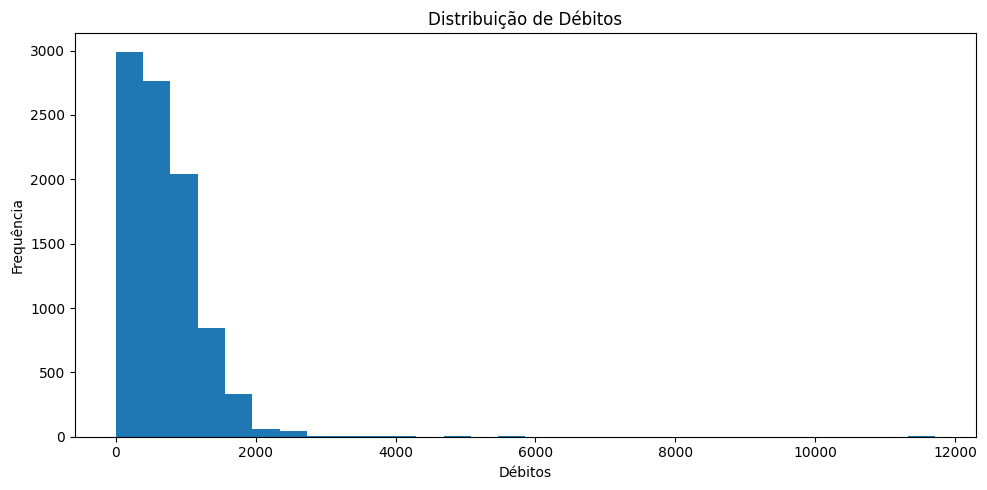

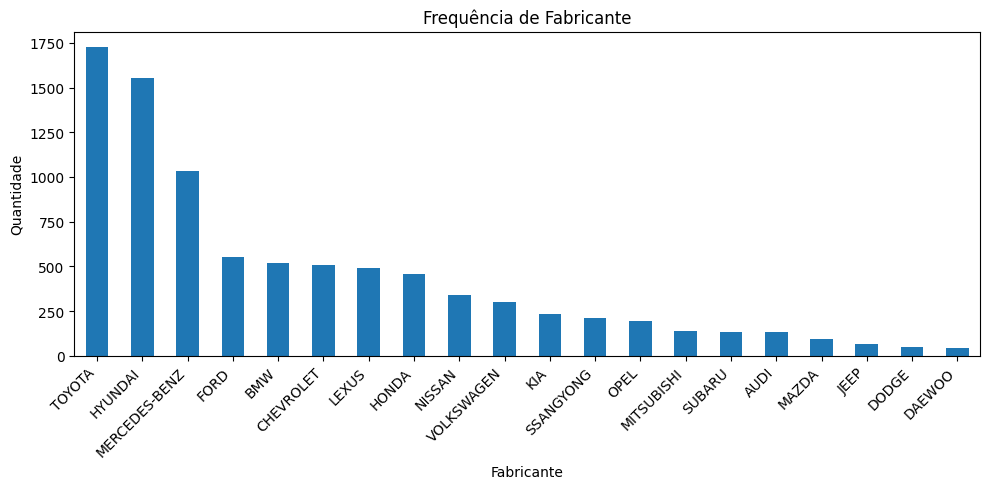

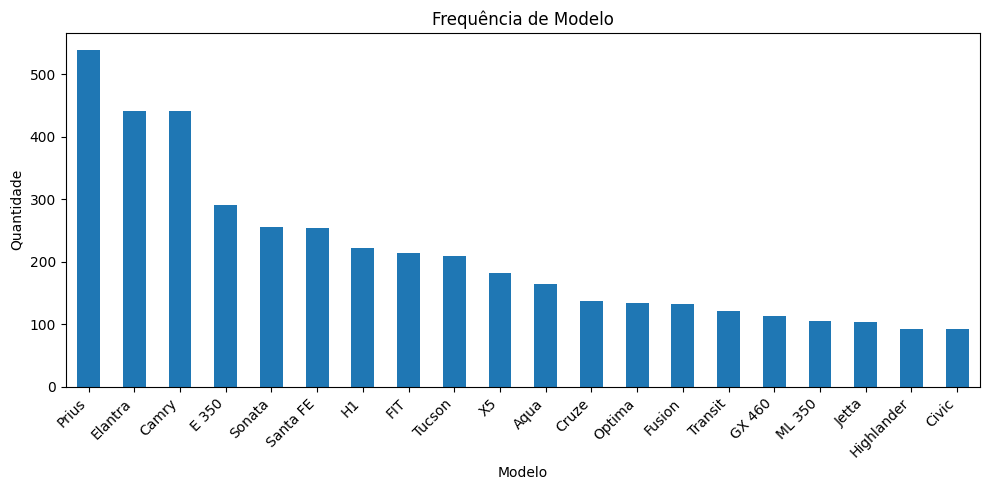

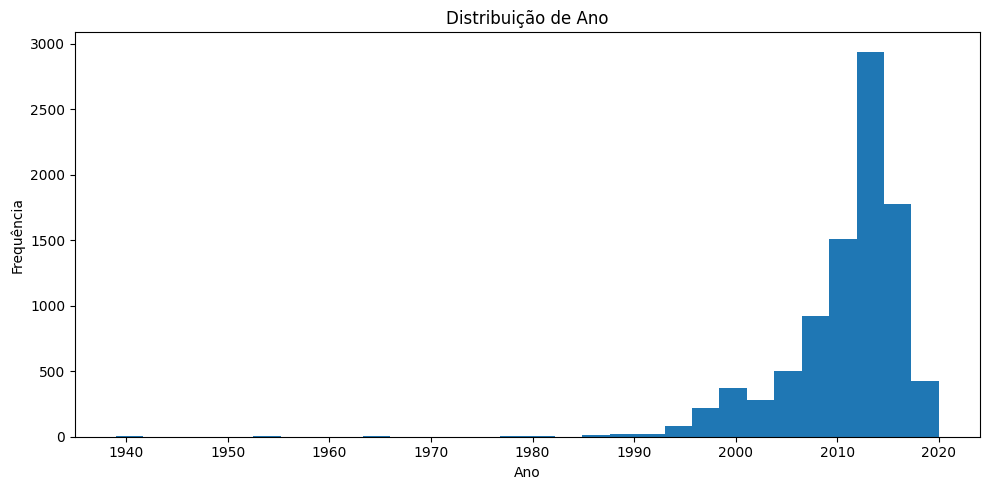

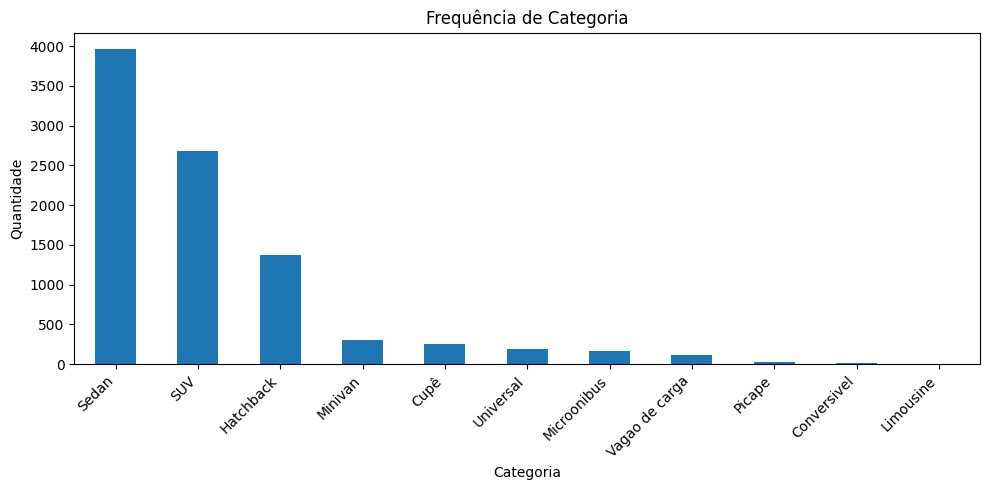

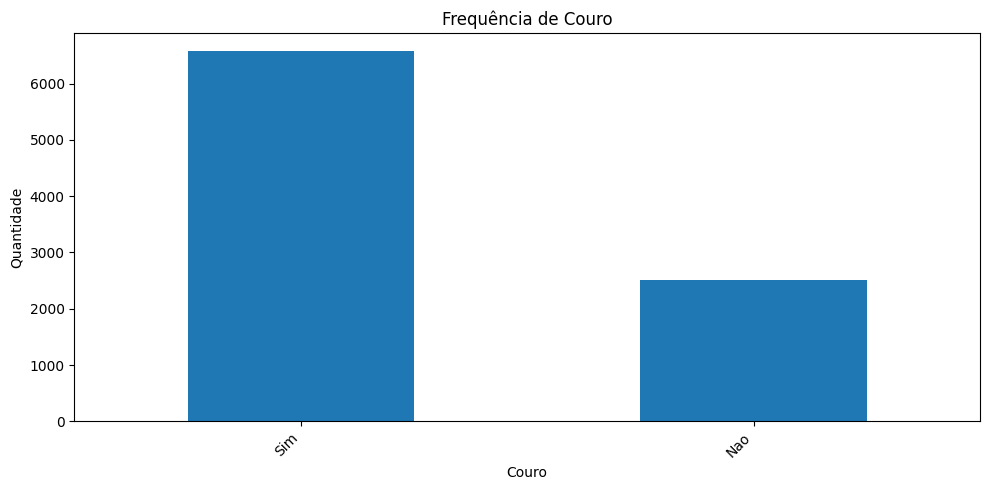

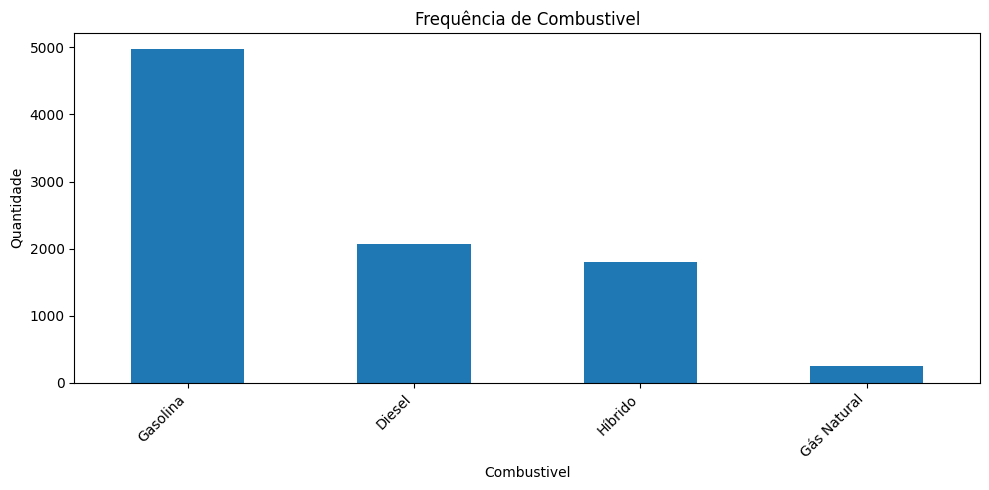

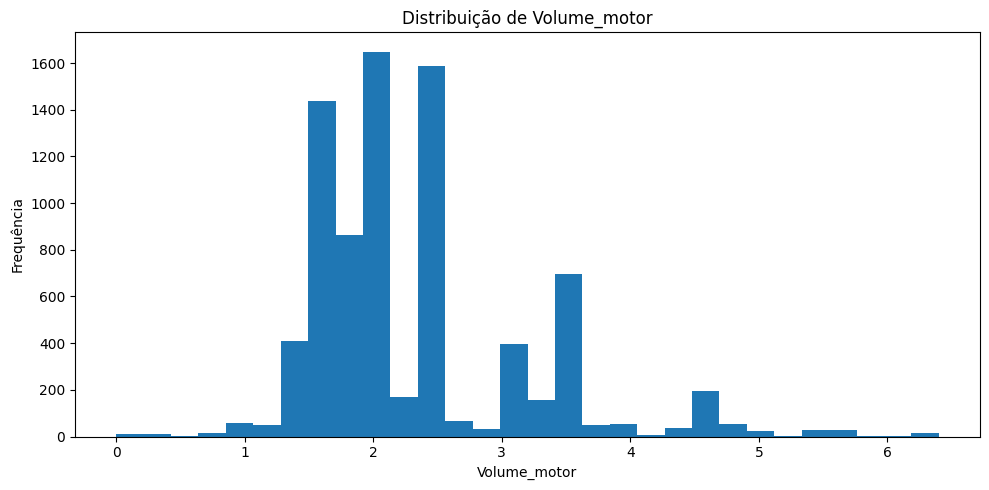

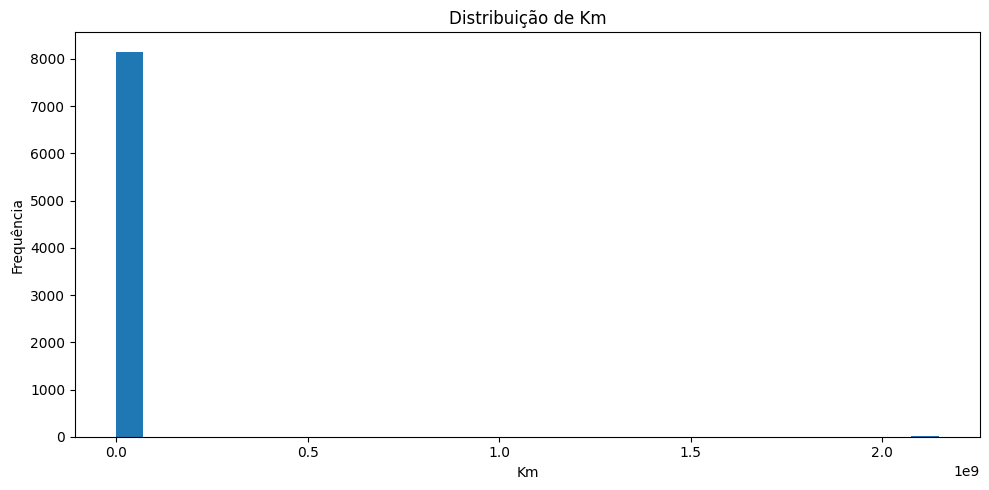

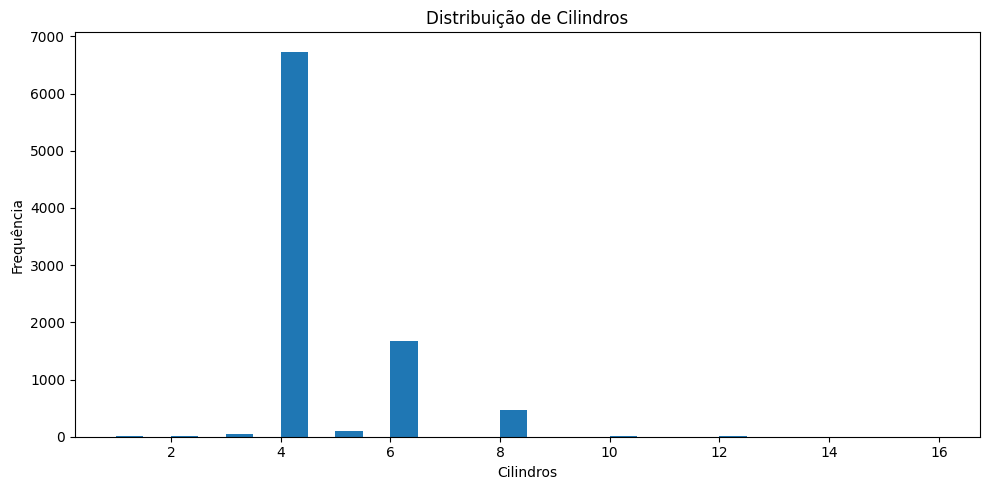

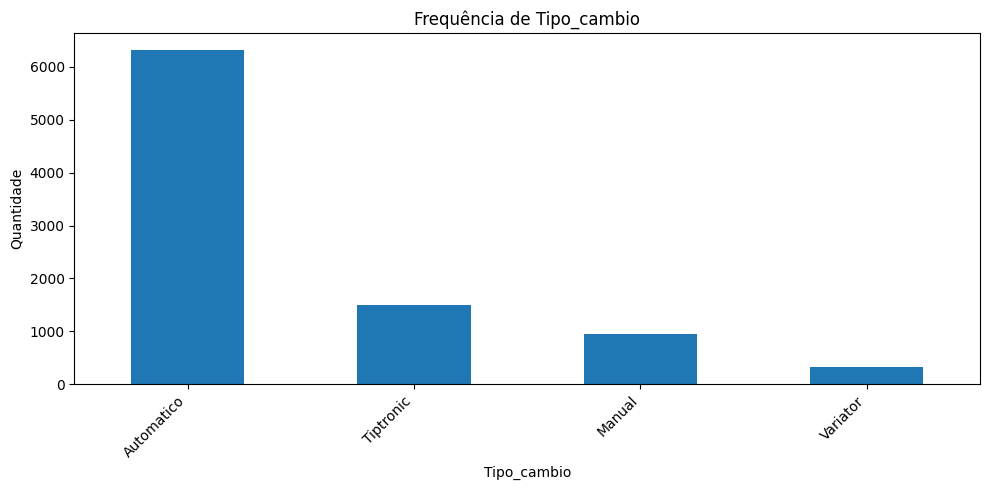

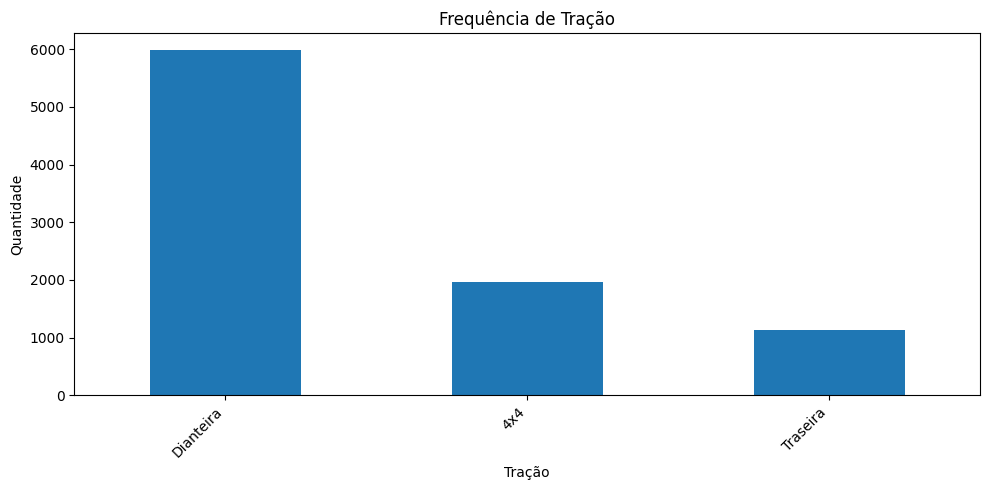

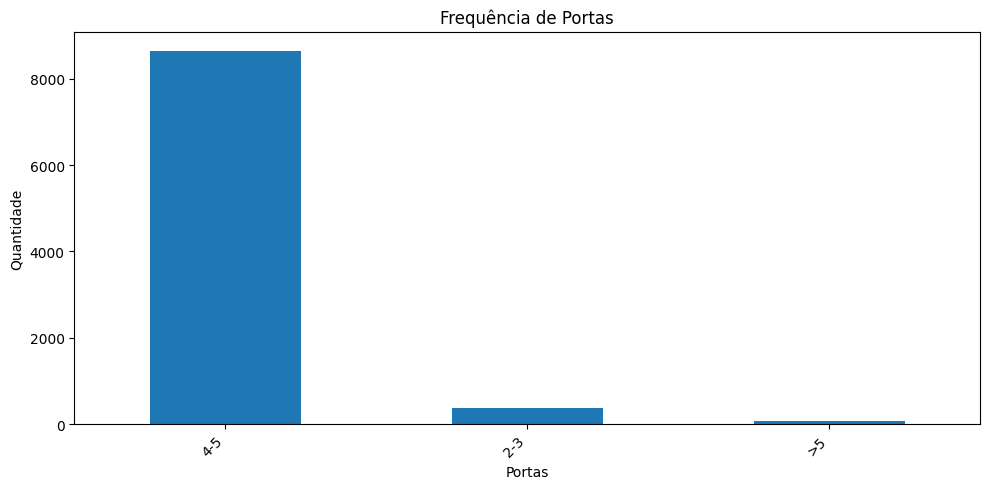

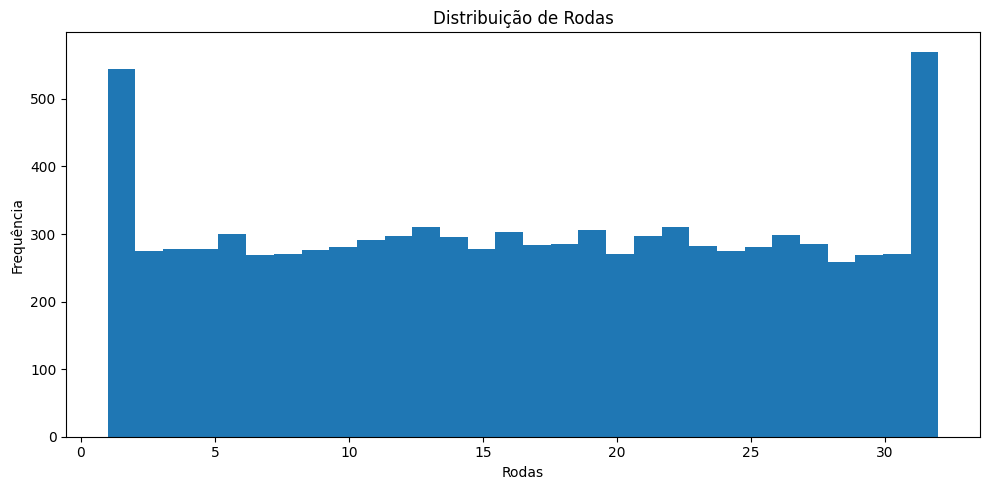

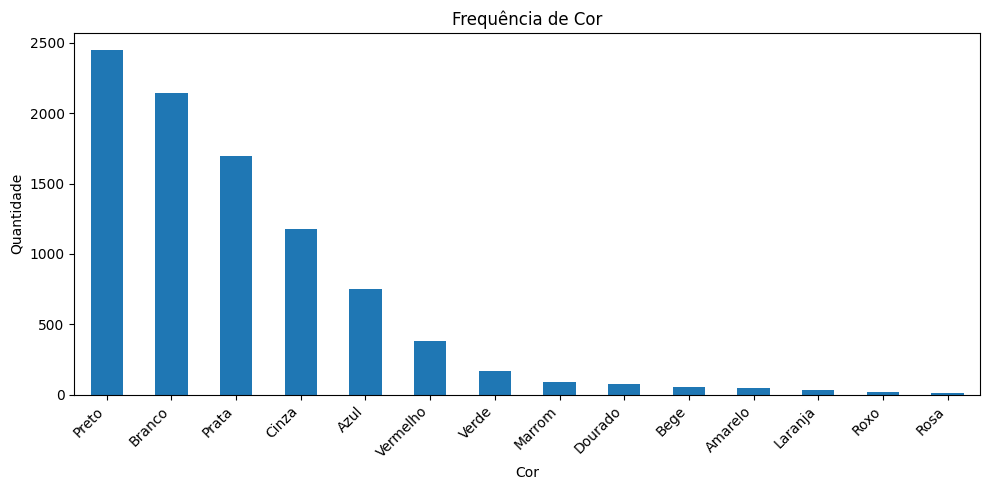

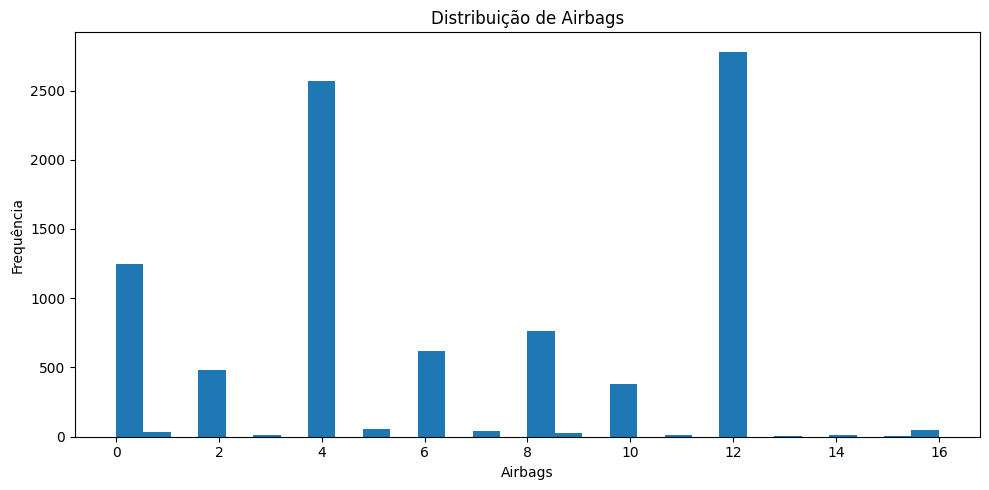

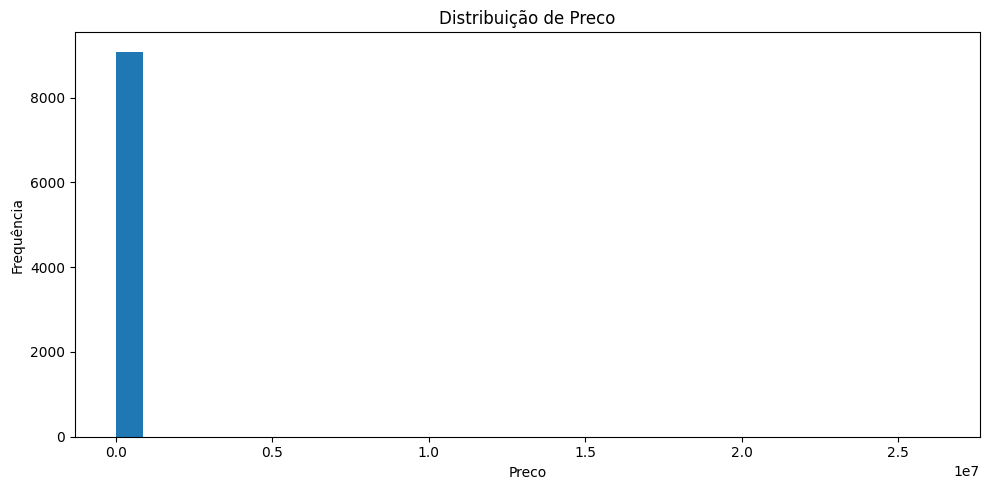

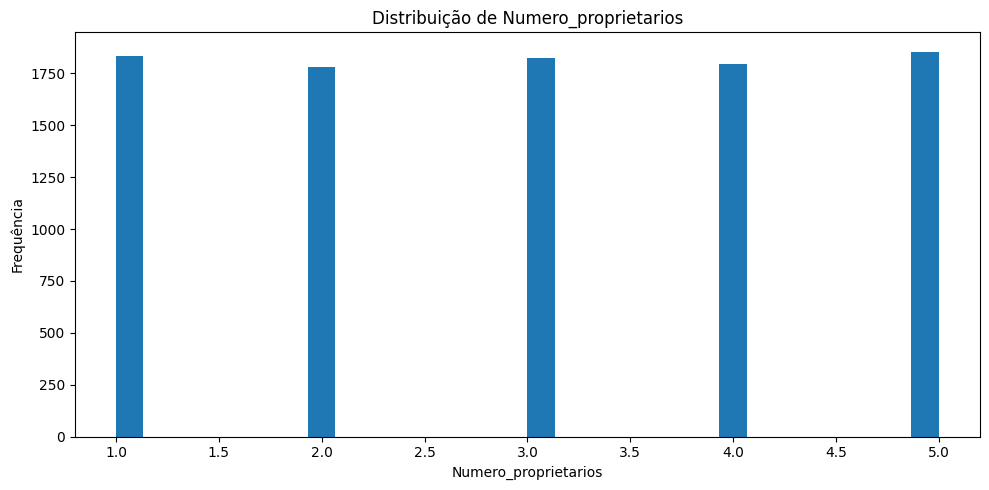

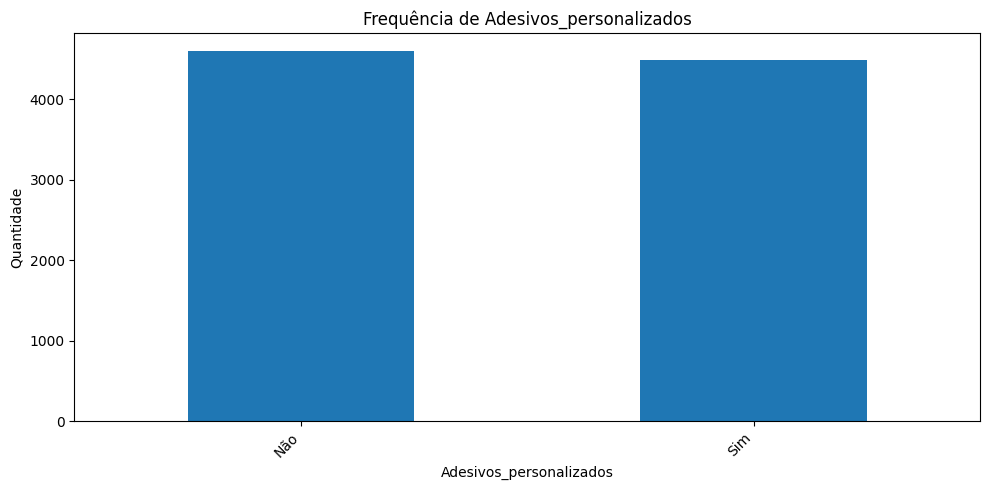

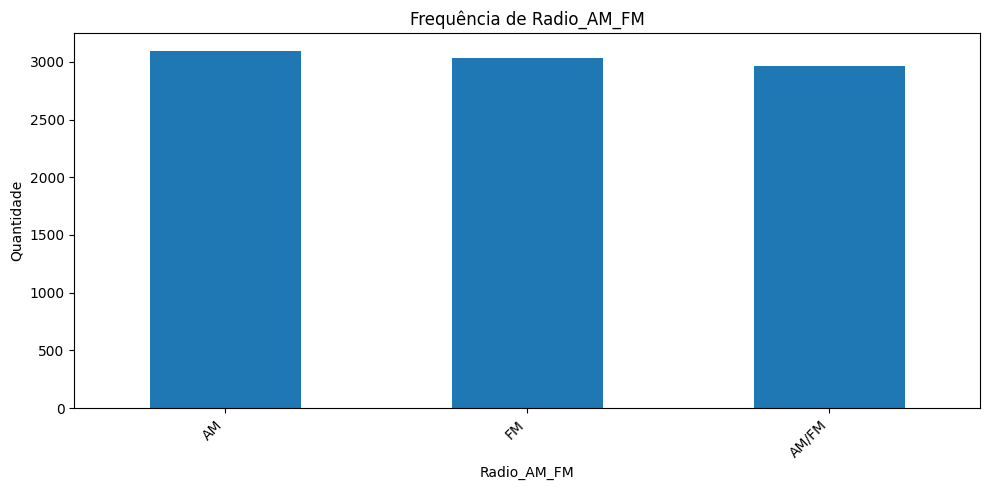

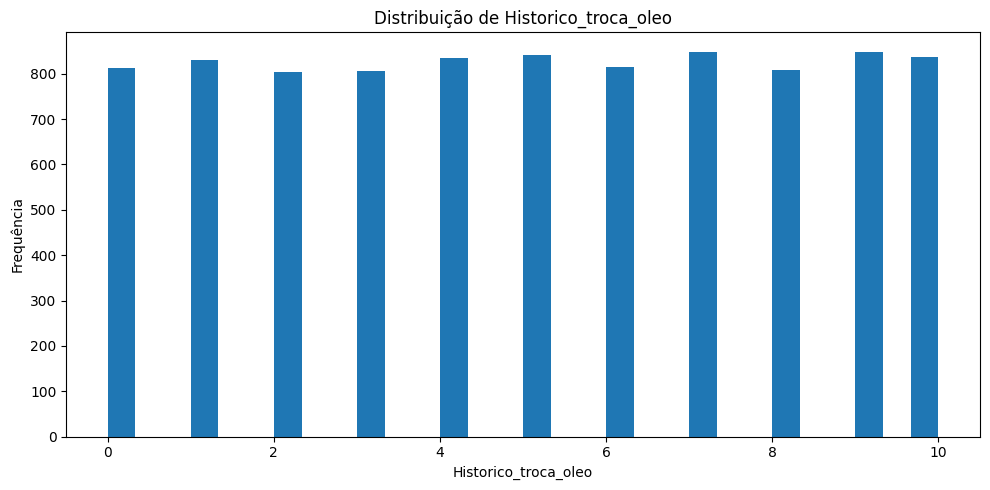

In [67]:
plt.rcParams["figure.figsize"] = (10, 5)

for col in df.columns:
    plt.figure()
    
    # tenta identificar se é numérica
    if pd.api.types.is_numeric_dtype(df[col]):
        df[col].dropna().plot(kind="hist", bins=30)
        plt.title(f"Distribuição de {col}")
        plt.xlabel(col)
        plt.ylabel("Frequência")
    
    else:
        contagem = df[col].astype(str).value_counts().head(20)
        contagem.plot(kind="bar")
        plt.title(f"Frequência de {col}")
        plt.xlabel(col)
        plt.ylabel("Quantidade")
        plt.xticks(rotation=45, ha="right")
    
    plt.tight_layout()
    plt.show()

# Predição de valores ausentes na coluna Volume_motor

#### Definição das features de interesse

In [68]:
features_vm = [
    "Fabricante",
    "Modelo",
    "Ano",
    "Categoria",
    "Combustivel",
    "Cilindros",
    "Tipo_cambio",
    "Tração",
    "Portas",
]

#### Filtrar somente as que não tem valores faltantes, treinar o modelo e verificar as métricas

In [69]:
df["Volume_motor"] = pd.to_numeric(df["Volume_motor"], errors="coerce")

df_vm = df[df["Volume_motor"].notna()].copy()

df_vm = df_vm.dropna(subset=features_vm)

X = df_vm[features_vm]
y = df_vm["Volume_motor"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

cat_cols = X_train.select_dtypes(include="object").columns.tolist()
num_cols = X_train.select_dtypes(exclude="object").columns.tolist()

preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ("num", "passthrough", num_cols)
])

model = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestRegressor(n_estimators=200, random_state=42))
])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.4f}")

MAE: 0.12
RMSE: 0.29
R²: 0.8934


#### Adicionar todos os dados e treinar o modelo novamente

In [70]:
# 1. treinar de novo usando TODOS os registros conhecidos
df["Volume_motor"] = pd.to_numeric(df["Volume_motor"], errors="coerce")

df_train_full = df[df["Volume_motor"].notna()].copy()
df_train_full = df_train_full.dropna(subset=features_vm)

X_full = df_train_full[features_vm]
y_full = df_train_full["Volume_motor"]

cat_cols = X_full.select_dtypes(include="object").columns.tolist()
num_cols = X_full.select_dtypes(exclude="object").columns.tolist()

preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ("num", "passthrough", num_cols)
])

model_final = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestRegressor(n_estimators=200, random_state=42))
])

model_final.fit(X_full, y_full)

# 2. selecionar só as linhas com Volume_motor faltante
df_missing = df[df["Volume_motor"].isna()].copy()

# 3. entre essas, pegar só as que têm todas as features necessárias
df_missing_valid = df_missing.dropna(subset=features_vm)

# 4. prever
preds = model_final.predict(df_missing_valid[features_vm])

# 5. preencher no dataframe original
df.loc[df_missing_valid.index, "Volume_motor"] = preds

# 6. conferir quantos faltantes sobraram
print("Faltantes restantes:", df["Volume_motor"].isna().sum())

Faltantes restantes: 0


# Predição de valores ausentes na coluna km

In [71]:
features_km = [
    "Fabricante",
    "Modelo",
    "Ano",
    "Categoria",
    "Combustivel",
    "Volume_motor",
    "Cilindros",
    "Tipo_cambio",
    "Tração",
    "Portas",
    "Rodas",
    "Numero_proprietarios",
    "Historico_troca_oleo"
]

In [72]:
train_km = df[df["Km"].notna()].copy()
pred_km = df[df["Km"].isna()].copy()

X_train_km = train_km[features_km]
y_train_km = train_km["Km"]

cat_km = X_train_km.select_dtypes(include="object").columns.tolist()
num_km = X_train_km.select_dtypes(exclude="object").columns.tolist()

prep_km = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_km),
    ("num", "passthrough", num_km)
])

model_km = Pipeline([
    ("prep", prep_km),
    ("model", RandomForestRegressor(n_estimators=200, random_state=42))
])

model_km.fit(X_train_km, y_train_km)

if len(pred_km) > 0:
    df.loc[df["Km"].isna(), "Km"] = model_km.predict(pred_km[features_km])

print(df[["Débitos", "Volume_motor", "Km"]].isna().sum())

Débitos         0
Volume_motor    0
Km              0
dtype: int64


In [73]:
df.head()

,Débitos,Fabricante,Modelo,Ano,Categoria,Couro,Combustivel,Volume_motor,Km,Cilindros,...,Tração,Portas,Rodas,Cor,Airbags,Preco,Numero_proprietarios,Adesivos_personalizados,Radio_AM_FM,Historico_troca_oleo
0,1017.0,HYUNDAI,Tucson,2017,SUV,Sim,Diesel,2.000000,4.808900e+04,4,...,Dianteira,4-5,17,Branco,4,40556.0,5,Não,FM,8
1,0.0,MERCEDES-BENZ,C 180,1995,Sedan,Nao,Gasolina,2.055817,1.578475e+07,4,...,Traseira,4-5,3,Prata,2,5331.0,2,Sim,FM,1
2,836.0,BMW,118,2010,Sedan,Sim,Diesel,2.000000,1.970000e+05,4,...,Dianteira,4-5,31,Preto,0,18817.0,5,Sim,AM,6
3,891.0,KIA,Sportage SX,2016,SUV,Sim,Gasolina,2.076915,5.544700e+04,4,...,Dianteira,4-5,18,Azul,10,22894.0,5,Não,FM,5
4,583.0,HYUNDAI,Elantra,2011,Sedan,Sim,Gasolina,1.600000,1.066160e+05,4,...,Dianteira,4-5,2,Preto,4,20005.0,1,Sim,AM,1


In [74]:
df.to_csv('database/test_tratado.csv', index=False)
#df.to_csv('database/train_mod_tratado.csv', index=False)